In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer, make_circles, make_moons
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()

cancer_X = cancer_df[cancer.feature_names]
cancer_y = cancer_df['target']

print(cancer_df.shape)
print(cancer.target_names)
display(cancer_df.head())

cancer_X_train, cancer_X_test, cancer_y_train, cancer_y_test = train_test_split(
    cancer_X,
    cancer_y,
    test_size=0.2,
    random_state=42,
    stratify=cancer_y
)

cancer_scaler = StandardScaler()
cancer_X_train_scaled = cancer_scaler.fit_transform(cancer_X_train)
cancer_X_test_scaled = cancer_scaler.transform(cancer_X_test)


(569, 31)
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 문제 7. PCA 2차원 데이터에서 Linear kernel과 RBF kernel 결정 경계 시각화

Breast Cancer 데이터는 feature가 30개라 결정 경계를 바로 2차원 그래프로 그리기 어려움.  
`PCA(n_components=2)`로 feature를 2개 주성분으로 줄인 뒤, `linear` 커널과 `rbf` 커널의 결정 경계를 비교함.

힌트:
- `PCA(n_components=2)`로 스케일링된 학습/평가 데이터를 2차원으로 줄임.
- PCA로 만든 2개 feature에서 SVC 모델을 다시 학습함.
- `DecisionBoundaryDisplay.from_estimator()`로 모델의 예측 영역을 그림.
- `sns.scatterplot()`으로 실제 정답 label의 산점도를 그림.
- 배경색은 모델이 예측한 영역이고, 점 색은 실제 정답 label임.

### 실행 결과
```text
PCA 학습 데이터 shape: (455, 2)
설명 분산 비율: [0.4441 0.1894]
누적 설명 분산 비율: 0.6336
그래프 출력: PCA 2차원 데이터에서 linear kernel과 rbf kernel의 결정 경계 비교
```


PCA 학습 데이터 shape: (455, 2)
설명 분산 비율: [0.4441 0.1894]
누적 설명 분산 비율: 0.6336


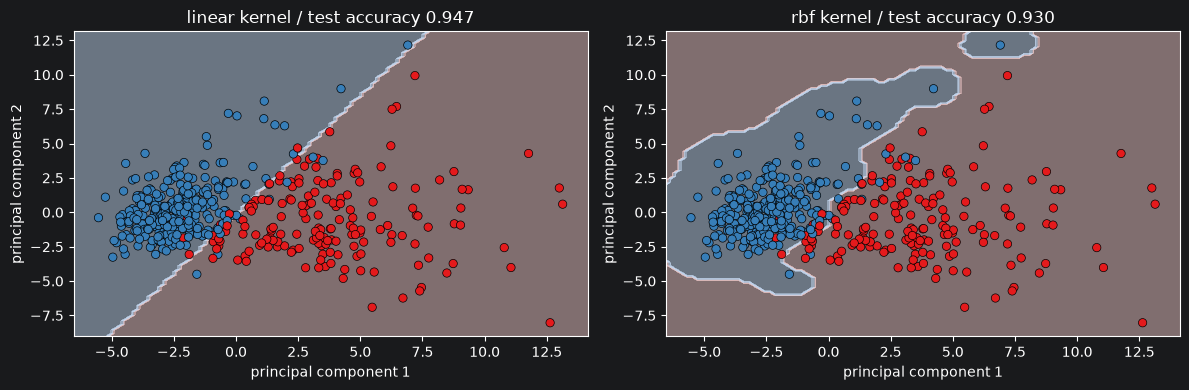

In [2]:
# PCA 2차원 데이터에서 linear kernel과 RBF kernel 결정 경계 시각화

# PCA(n_components=2): 30개 feature를 시각화 가능한 2개 축으로 압축함.
# 이미 스케일링된 데이터를 사용해야 PCA 축이 특정 feature 크기에 과하게 끌려가지 않음.
pca = PCA(n_components=2)
cancer_X_train_pca = pca.fit_transform(cancer_X_train_scaled)
cancer_X_test_pca = pca.transform(cancer_X_test_scaled)

print('PCA 학습 데이터 shape:', cancer_X_train_pca.shape)
print('설명 분산 비율:', np.round(pca.explained_variance_ratio_, 4))
print('누적 설명 분산 비율:', np.round(pca.explained_variance_ratio_.sum(), 4))

# ListedColormap(): 예측 영역의 색을 직접 지정함.
# 0번 malignant는 연한 빨강, 1번 benign은 연한 파랑 배경으로 표시함.
boundary_cmap = ListedColormap(['#ffd6d6', '#cfe5ff'])
point_palette = {'malignant': '#e41a1c', 'benign': '#377eb8'}

# target 숫자 0, 1을 사람이 읽기 좋은 클래스 이름으로 바꿈.
cancer_y_train_name = pd.Series(cancer_y_train).map(dict(enumerate(cancer.target_names)))

# PCA 2차원 데이터에 linear kernel과 RBF kernel을 각각 학습시켜 비교함.
pca_svc_models = {
    'linear': SVC(kernel='linear', C=1.0, random_state=42),
    'rbf': SVC(kernel='rbf', C=1.0, gamma=0.5, random_state=42)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, pca_svc_models.items()):
    # fit(): PCA로 줄인 2개 feature에서 SVC 결정 경계를 학습함.
    model.fit(cancer_X_train_pca, cancer_y_train)

    # DecisionBoundaryDisplay.from_estimator(): 2차원 좌표 공간에서 모델의 예측 영역을 배경색으로 그림.
    DecisionBoundaryDisplay.from_estimator(
        model,
        cancer_X_train_pca,
        response_method='predict',
        plot_method='contourf',
        alpha=0.45,
        cmap=boundary_cmap,
        ax=ax
    )

    # scatterplot(): 실제 학습 데이터의 정답 label을 점 색으로 표시함.
    # 배경색은 모델 예측 영역이고, 점 색은 실제 정답임.
    sns.scatterplot(
        x=cancer_X_train_pca[:, 0],
        y=cancer_X_train_pca[:, 1],
        hue=cancer_y_train_name,
        palette=point_palette,
        edgecolor='black',
        legend=False,
        ax=ax
    )

    ax.set_title(f'{name} kernel / test accuracy {model.score(cancer_X_test_pca, cancer_y_test):.3f}')
    ax.set_xlabel('principal component 1')
    ax.set_ylabel('principal component 2')

plt.tight_layout()
plt.show()


## 문제 8. `make_circles` 데이터에서 RBF 커널 결정 경계 시각화

`make_circles()`는 안쪽 원과 바깥쪽 원으로 나뉜 비선형 분류 데이터임.  
직선 하나로는 안쪽/바깥쪽을 나누기 어렵기 때문에, `linear` 커널과 `rbf` 커널의 차이를 확인하기 좋음.

힌트:
- `make_circles()`로 원형 비선형 데이터를 생성함.
- `StandardScaler`로 feature 스케일을 맞춤.
- `SVC(kernel='linear')`와 `SVC(kernel='rbf')`를 각각 학습함.
- `DecisionBoundaryDisplay.from_estimator()`로 모델의 예측 영역을 그림.
- 점 색은 실제 정답 label이고, 배경색은 모델이 예측한 영역임.

### 실행 결과
```text
 model  train_accuracy  test_accuracy  support_vector_count
linear        0.566667           0.54                   298
   rbf        1.000000           1.00                    36
그래프 출력: make_circles 데이터에서 linear kernel과 rbf kernel의 결정 경계 비교
```


,model,train_accuracy,test_accuracy,support_vector_count
0,linear,0.562667,0.58,750
1,rbf,1.000000,1.00,130


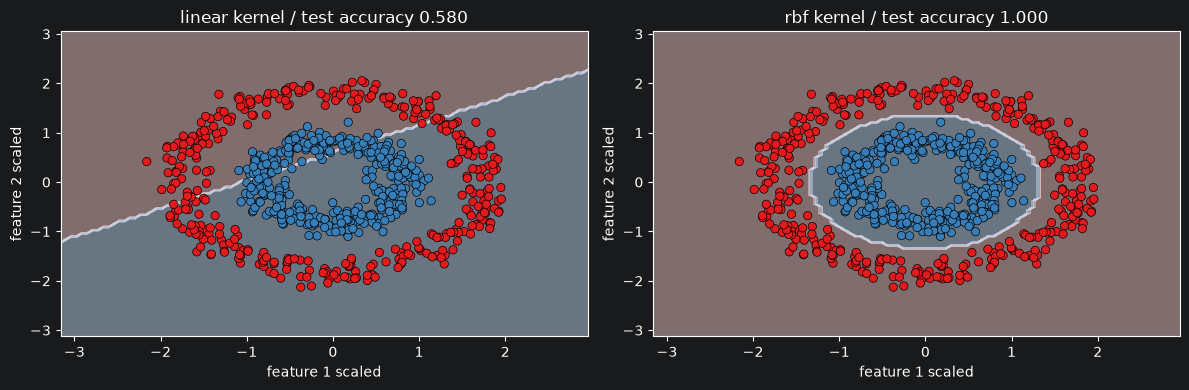

In [4]:
# make_circles 데이터에서 linear kernel과 RBF kernel 결정 경계 시각화

# make_circles(): 안쪽 원과 바깥쪽 원으로 나뉜 비선형 분류 데이터를 생성함.
# factor: 안쪽 원의 크기 비율, noise: 데이터에 섞을 흔들림 정도임.
circle_X, circle_y = make_circles(
    n_samples=1000,
    factor=0.45,
    noise=0.08,
    random_state=42
)

circle_X_train, circle_X_test, circle_y_train, circle_y_test = train_test_split(
    circle_X,
    circle_y,
    test_size=0.25,
    random_state=42,
    stratify=circle_y
)

# SVM은 거리와 마진을 보므로, 원형 데이터에서도 스케일링을 적용함.
circle_scaler = StandardScaler()
circle_X_train_scaled = circle_scaler.fit_transform(circle_X_train)
circle_X_test_scaled = circle_scaler.transform(circle_X_test)

# linear는 직선 경계, rbf는 곡선형 경계를 만들 수 있음.
circle_models = {
    'linear': SVC(kernel='linear', C=1.0, random_state=42),
    'rbf': SVC(kernel='rbf', C=1.0, gamma=0.1, random_state=42)
}

circle_results = []
boundary_cmap = ListedColormap(['#ffd6d6', '#cfe5ff'])
point_palette = {0: '#e41a1c', 1: '#377eb8'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, circle_models.items()):
    # fit(): 현재 커널 설정으로 원형 데이터를 학습함.
    model.fit(circle_X_train_scaled, circle_y_train)

    circle_results.append({
        'model': name,
        'train_accuracy': model.score(circle_X_train_scaled, circle_y_train),
        'test_accuracy': model.score(circle_X_test_scaled, circle_y_test),
        'support_vector_count': len(model.support_)
    })

    # 배경색은 모델의 예측 영역을 의미함.
    DecisionBoundaryDisplay.from_estimator(
        model,
        circle_X_train_scaled,
        response_method='predict',
        plot_method='contourf',
        alpha=0.45,
        cmap=boundary_cmap,
        ax=ax
    )

    # 점 색은 실제 정답 label을 의미함.
    sns.scatterplot(
        x=circle_X_train_scaled[:, 0],
        y=circle_X_train_scaled[:, 1],
        hue=circle_y_train,
        palette=point_palette,
        edgecolor='black',
        legend=False,
        ax=ax
    )

    ax.set_title(f'{name} kernel / test accuracy {model.score(circle_X_test_scaled, circle_y_test):.3f}')
    ax.set_xlabel('feature 1 scaled')
    ax.set_ylabel('feature 2 scaled')

circle_result_df = pd.DataFrame(circle_results)
display(circle_result_df)

plt.tight_layout()
plt.show()
